In [14]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV , learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
df=pd.read_csv("fps_benchmark.csv")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24624 entries, 0 to 24623
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CpuName                    24624 non-null  object 
 1   CpuNumberOfCores           24624 non-null  float64
 2   CpuNumberOfThreads         24624 non-null  float64
 3   CpuBaseClock               24624 non-null  float64
 4   CpuCacheL1                 24624 non-null  float64
 5   CpuCacheL2                 24624 non-null  float64
 6   CpuCacheL3                 24624 non-null  float64
 7   CpuDieSize                 11664 non-null  float64
 8   CpuFrequency               24624 non-null  float64
 9   CpuMultiplier              24624 non-null  float64
 10  CpuMultiplierUnlocked      24624 non-null  object 
 11  CpuProcessSize             24624 non-null  float64
 12  CpuTDP                     24624 non-null  float64
 13  CpuNumberOfTransistors     11664 non-null  flo

In [17]:
df.describe()

,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,CpuProcessSize,...,GpuMemorySize,GpuPixelRate,GpuProcessSize,GpuNumberOfROPs,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GameResolution,FPS
count,24624.000000,24624.000000,24624.0,24624.000000,24624.000000,24624.000000,11664.000000,24624.000000,24624.000000,24624.000000,...,24624.000000,24624.000000,24624.000000,24624.000000,24624.00000,24624.000000,24624.000000,24624.000000,24624.0,24624.000000
mean,6.315789,10.842105,100.0,515.368421,2506.105263,18.210526,0.000126,3589.473684,35.894737,11.947368,...,7333.333333,89045.925926,15.259259,57.777778,2237.62963,139.851852,215336.296296,8377.777778,1080.0,123.959369
std,2.078823,5.203982,0.0,233.521609,1398.698066,14.229906,0.000059,317.719889,3.177199,3.017095,...,2775.611026,28211.657786,5.783828,19.023439,866.31581,54.144738,83501.932511,3533.754477,0.0,54.610080
min,2.000000,4.000000,100.0,128.000000,512.000000,3.000000,0.000074,2800.000000,28.000000,7.000000,...,3000.000000,36430.000000,7.000000,24.000000,768.00000,48.000000,66820.000000,3300.000000,1080.0,22.200000
25%,6.000000,6.000000,100.0,384.000000,1536.000000,9.000000,0.000074,3400.000000,34.000000,7.000000,...,6000.000000,68360.000000,12.000000,48.000000,1536.00000,96.000000,157100.000000,5700.000000,1080.0,83.600000
50%,6.000000,12.000000,100.0,512.000000,2048.000000,16.000000,0.000074,3600.000000,36.000000,14.000000,...,8000.000000,86400.000000,14.000000,64.000000,2304.00000,144.000000,202000.000000,7200.000000,1080.0,114.300000
75%,8.000000,16.000000,100.0,576.000000,3072.000000,32.000000,0.000192,3800.000000,38.000000,14.000000,...,8000.000000,109400.000000,16.000000,64.000000,2560.00000,160.000000,277300.000000,10800.000000,1080.0,154.100000
max,12.000000,24.000000,100.0,1152.000000,6144.000000,64.000000,0.000192,4200.000000,42.000000,14.000000,...,16000.000000,139200.000000,28.000000,96.000000,4352.00000,272.000000,420200.000000,18600.000000,1080.0,396.400000


In [18]:
# Filter and display only columns that have at least one NaN
nan_report = df.isnull().sum()[df.isnull().sum() > 0]

print("Columns with NaN values and their counts:")
print(nan_report)

Columns with NaN values and their counts:
CpuDieSize                   12960
CpuNumberOfTransistors       12960
GpuNumberOfComputeUnits      19152
GpuNumberOfExecutionUnits    24624
dtype: int64


<Axes: >

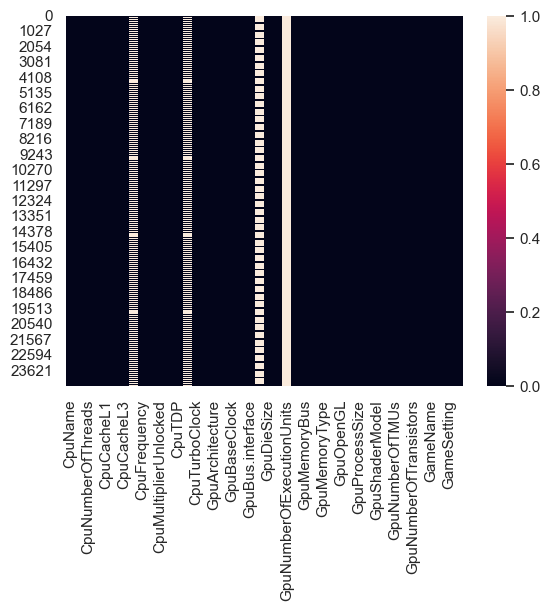

In [19]:
sns.heatmap(df.isnull())

Skewness : 1.05
Kurtosis : 1.42


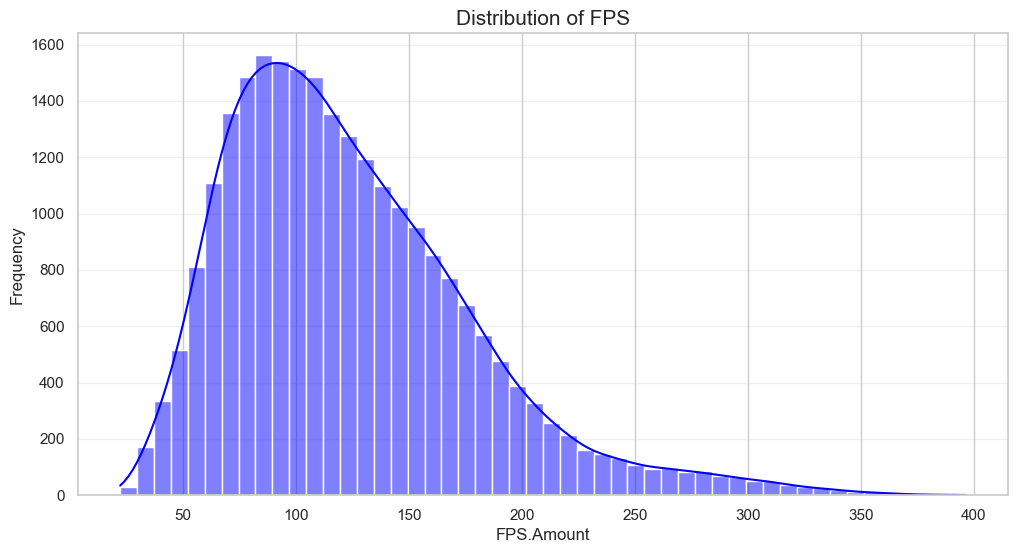

In [20]:

plt.figure(figsize=(12, 6))
sns.histplot(df['FPS'], kde=True, color='blue', bins=50)
plt.title('Distribution of FPS', fontsize=15)
plt.xlabel('FPS.Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

print(f"Skewness : {df['FPS'].skew():.2f}")
print(f"Kurtosis : {df['FPS'].kurt():.2f}")

plt.show()

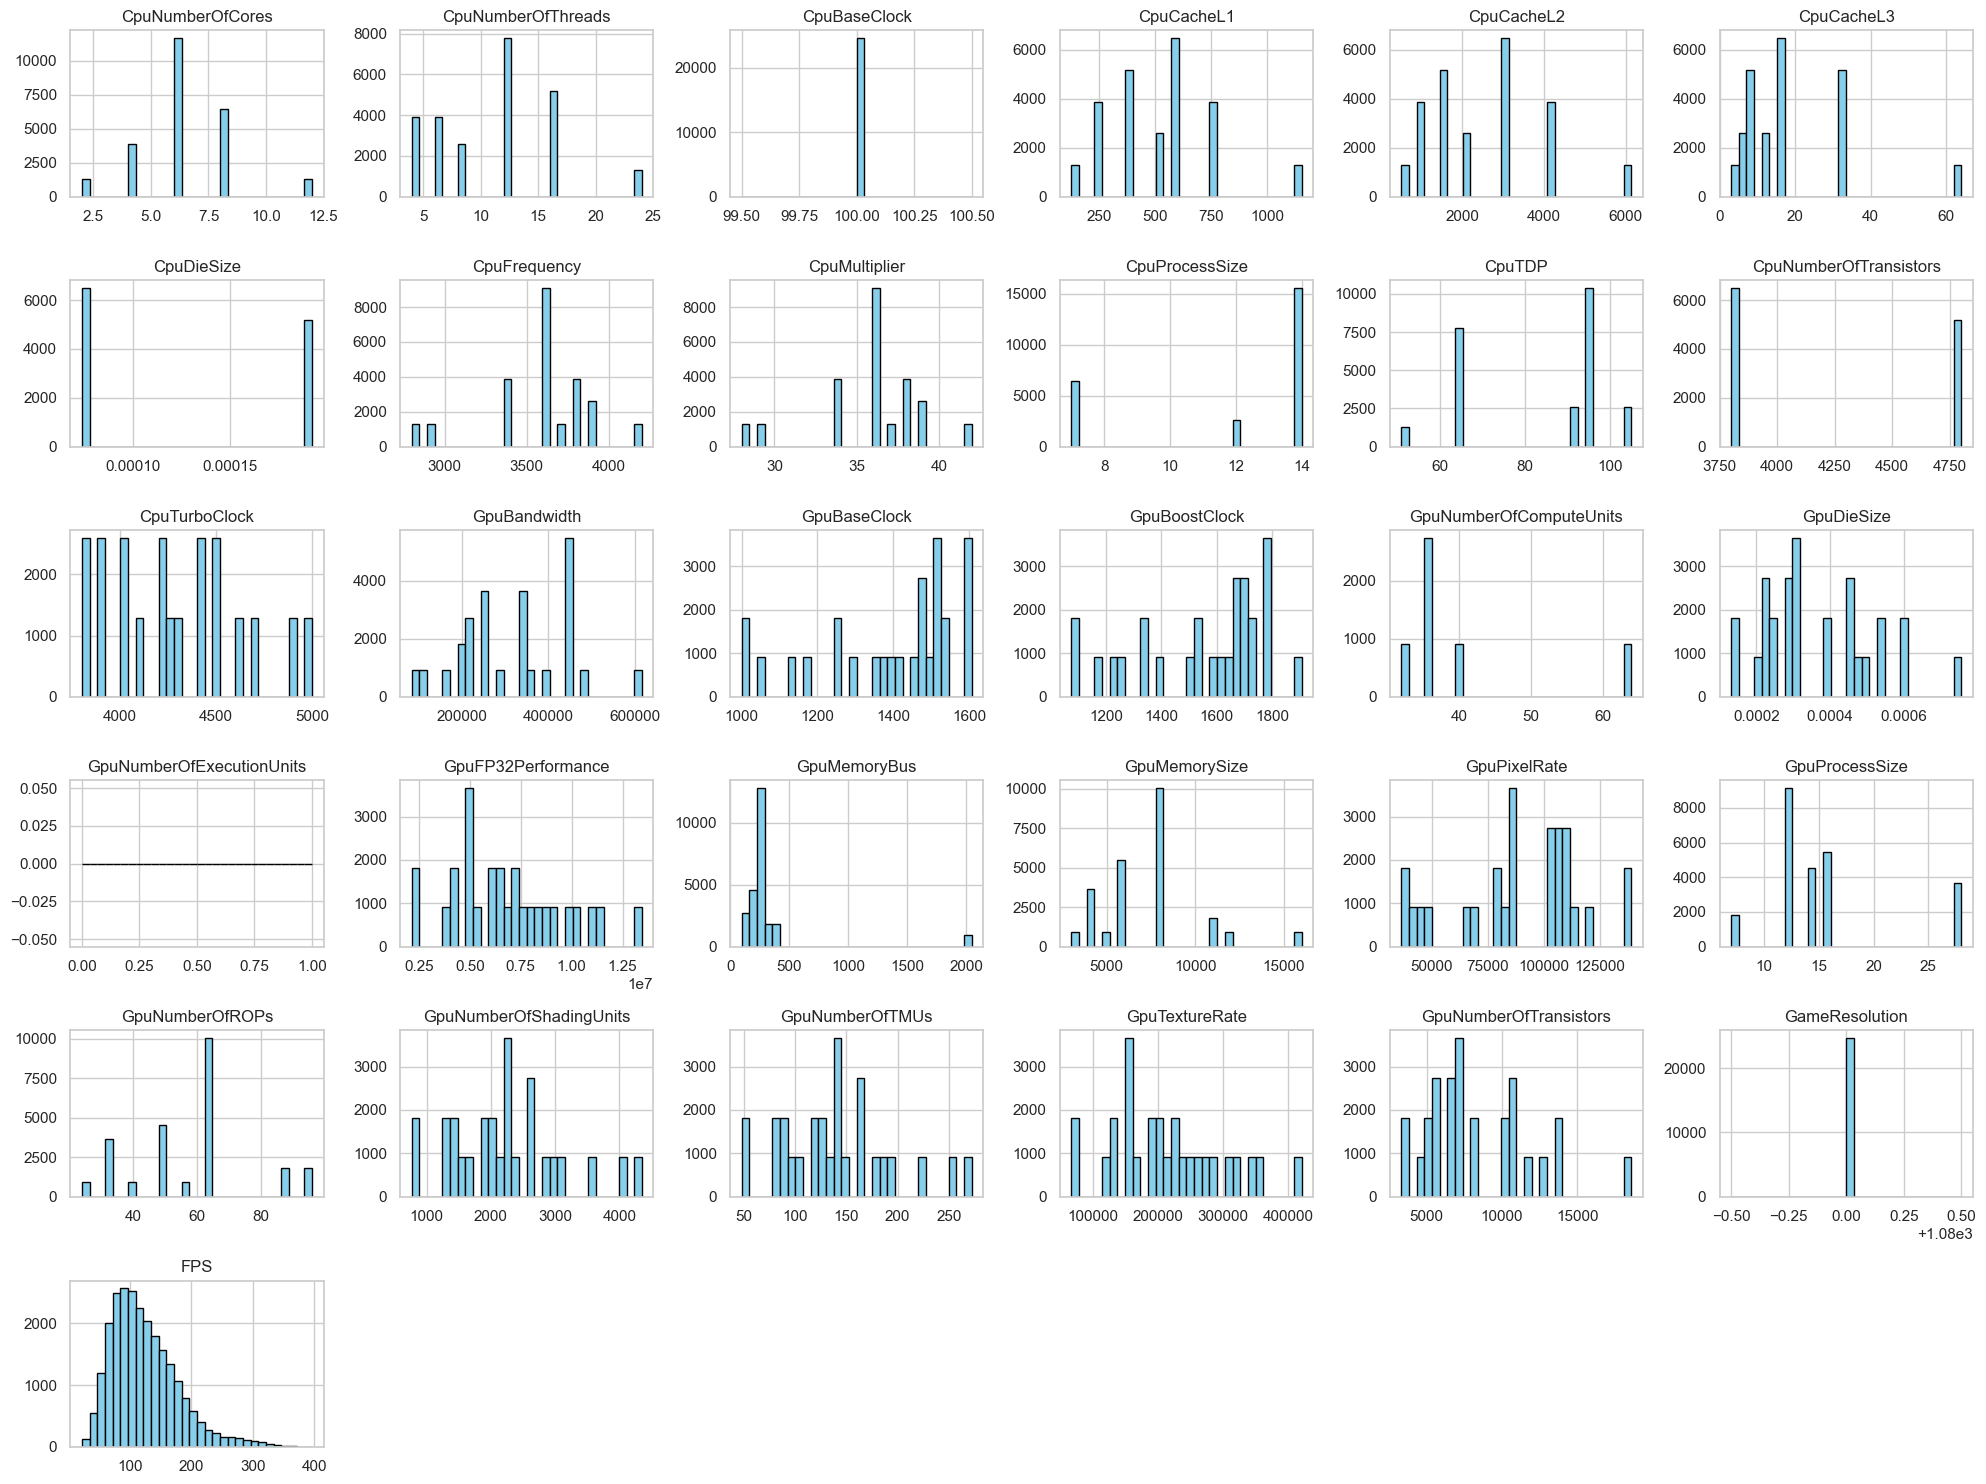

In [21]:

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_features].hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

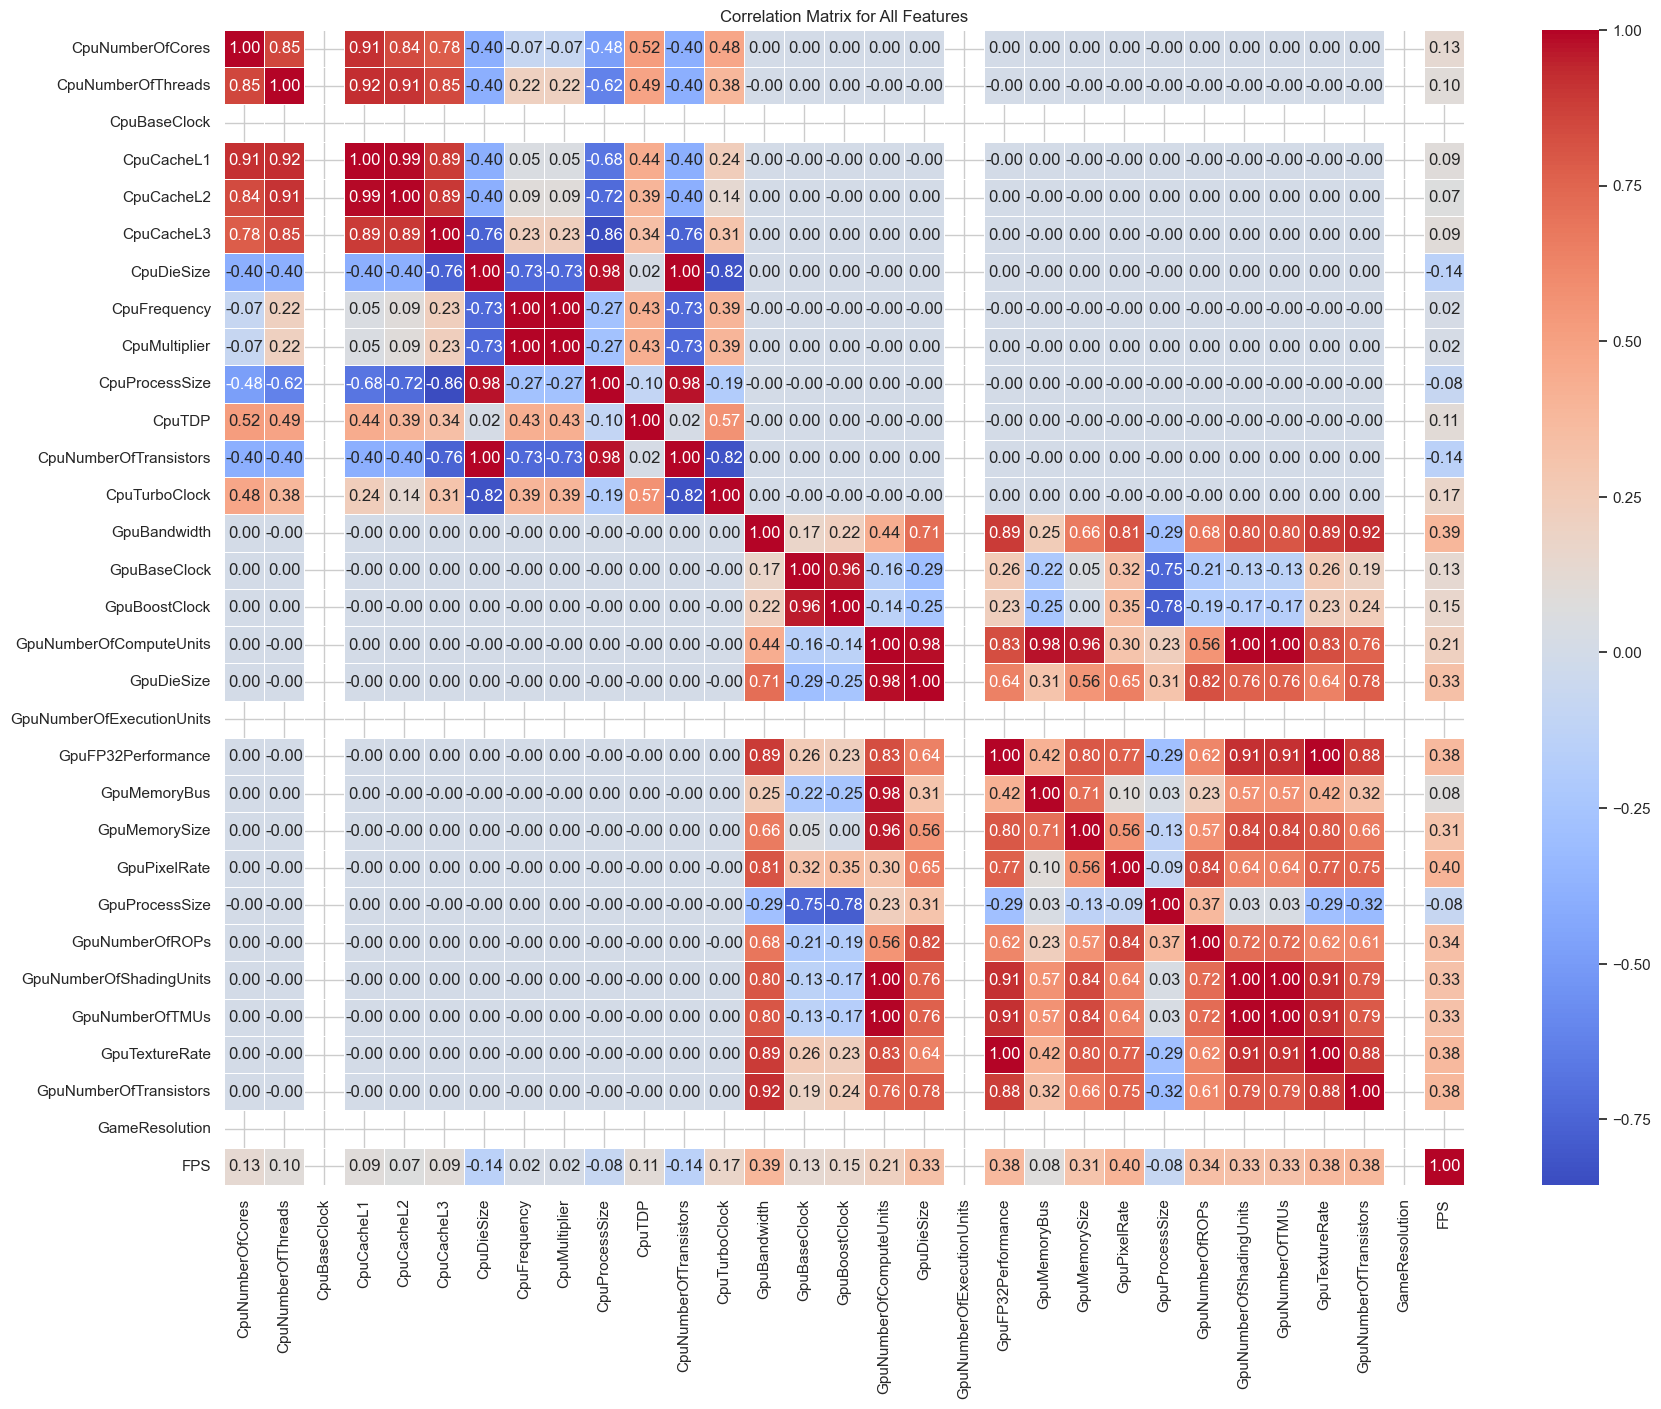

C:\Users\Compumarts\AppData\Local\Temp\ipykernel_18768\2935778538.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


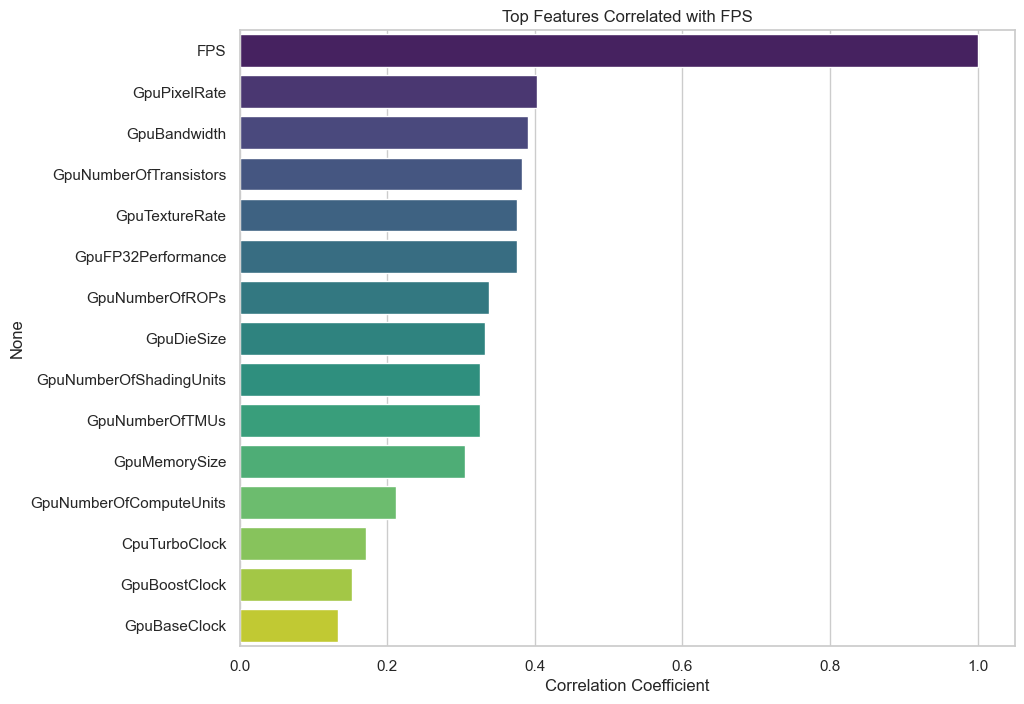

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.select_dtypes(include=['number']).corr()


plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix for All Features")
plt.show()
top_corr = corr_matrix['FPS'].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title("Top Features Correlated with FPS")
plt.xlabel("Correlation Coefficient")
plt.show()

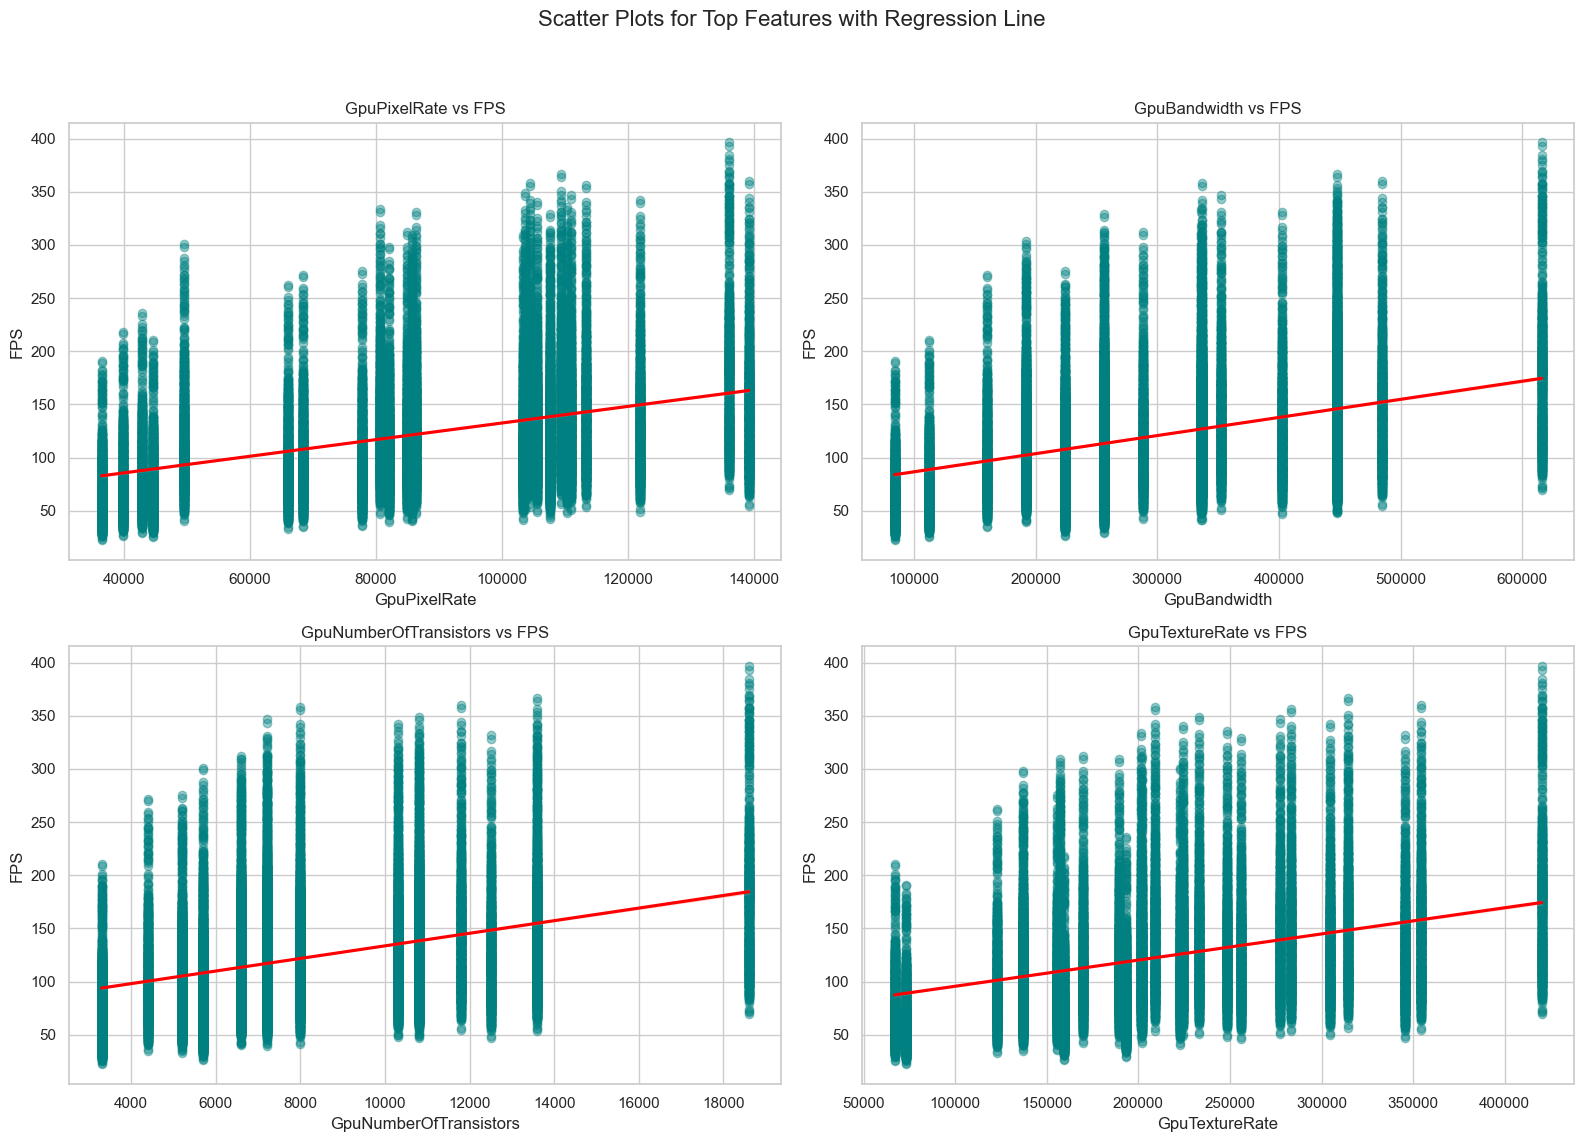

In [23]:

top_4_features = ['GpuPixelRate', 'GpuBandwidth', 'GpuNumberOfTransistors', 'GpuTextureRate']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Scatter Plots for Top Features with Regression Line', fontsize=16)

for i, col in enumerate(top_4_features):
    row, ax_idx = divmod(i, 2)
    sns.regplot(data=df, x=col, y='FPS', ax=axes[row, ax_idx], 
                scatter_kws={'alpha':0.4, 'color':'teal'}, 
                line_kws={'color':'red'})
    axes[row, ax_idx].set_title(f'{col} vs FPS')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ==========================================
# 1. Data Preparation
# ==========================================

cols_to_drop = [
    'GpuNumberOfExecutionUnits', 'GpuNumberOfComputeUnits',
    'CpuDieSize', 'CpuNumberOfTransistors',
    'CpuBaseClock', 'GameResolution'
]
df_cleaned = df.drop(columns=cols_to_drop)

X = df_cleaned.drop('FPS', axis=1)
y = df_cleaned['FPS']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Feature Classification
# ==========================================
high_cardinality_cols = ['CpuName', 'GpuName', 'GameName']
low_cardinality_cols = [col for col in X.select_dtypes(include=['object']).columns if col not in high_cardinality_cols]
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# ==========================================
# 3. Building the Preprocessing Pipelines
# ==========================================

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


low_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat_low', low_cat_transformer, low_cardinality_cols),
        ('cat_high', high_cat_transformer, high_cardinality_cols)
    ])

# ==========================================
# 4. Define Models to Compare
# ==========================================
models = {
    'Ridge (Baseline)': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

# ==========================================
# 5. Training and Comprehensive Evaluation
# ==========================================
print("Starting Model Evaluation with 5-Fold Cross Validation...\n")

results = []

for name, model in models.items():

    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    
    cv_scores = cross_validate(
        full_pipeline, X_train, y_train, 
        cv=5, 
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
        n_jobs=-1
    )
    

    mean_mae = -cv_scores['test_neg_mean_absolute_error'].mean()
    mean_rmse = -cv_scores['test_neg_root_mean_squared_error'].mean()
    mean_r2 = cv_scores['test_r2'].mean()
    
    results.append({
        'Model': name,
        'MAE': mean_mae,
        'RMSE': mean_rmse,
        'R2 Score': mean_r2
    })


results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print(results_df.to_string(index=False))
# ==========================================
# 6. Final Test on the Best Model (Optional)
# ==========================================

best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42))
])

best_model_pipeline.fit(X_train, y_train)
final_predictions = best_model_pipeline.predict(X_test)


Starting Model Evaluation with 5-Fold Cross Validation...

           Model      MAE      RMSE  R2 Score
        LightGBM 1.026720  1.382330  0.999361
         XGBoost 1.152973  1.603815  0.999142
   Random Forest 1.110868  1.782580  0.998935
Ridge (Baseline) 7.744895 11.809373  0.953484


Generating Model Comparison Plots...


C:\Users\Compumarts\AppData\Local\Temp\ipykernel_18768\1458917224.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[0], palette='viridis')
C:\Users\Compumarts\AppData\Local\Temp\ipykernel_18768\1458917224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df, ax=axes[1], palette='flare')


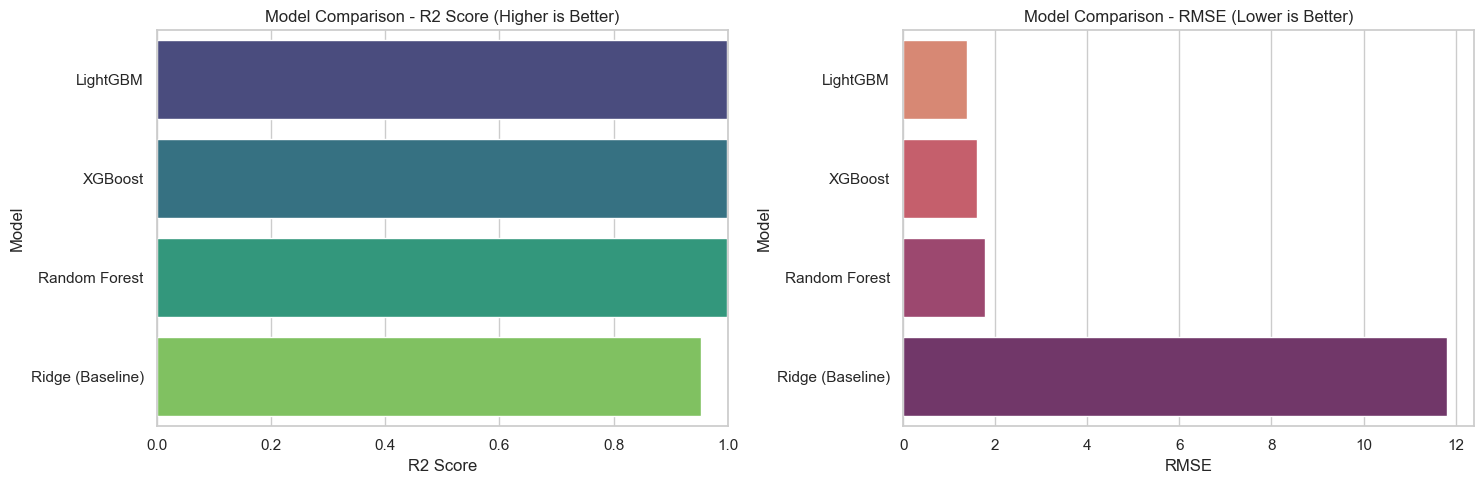

Generating Learning Curve for the Best Model...


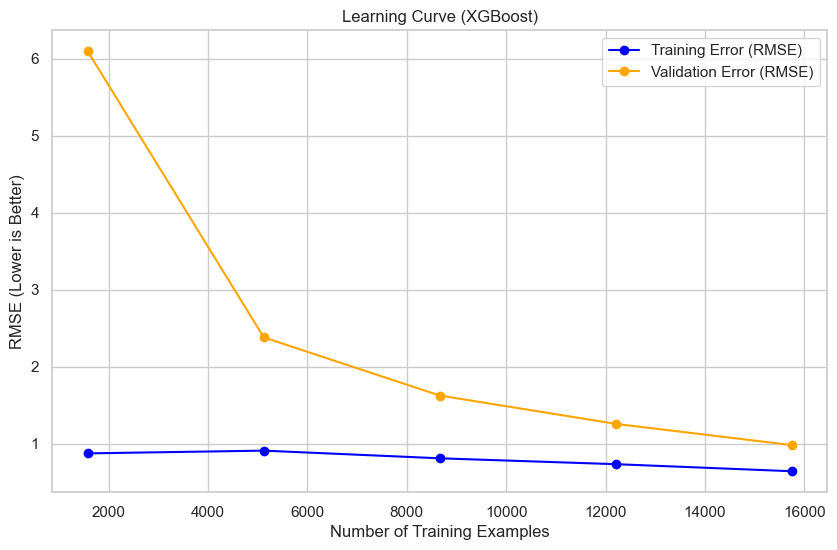

Generating Actual vs Predicted Plot...


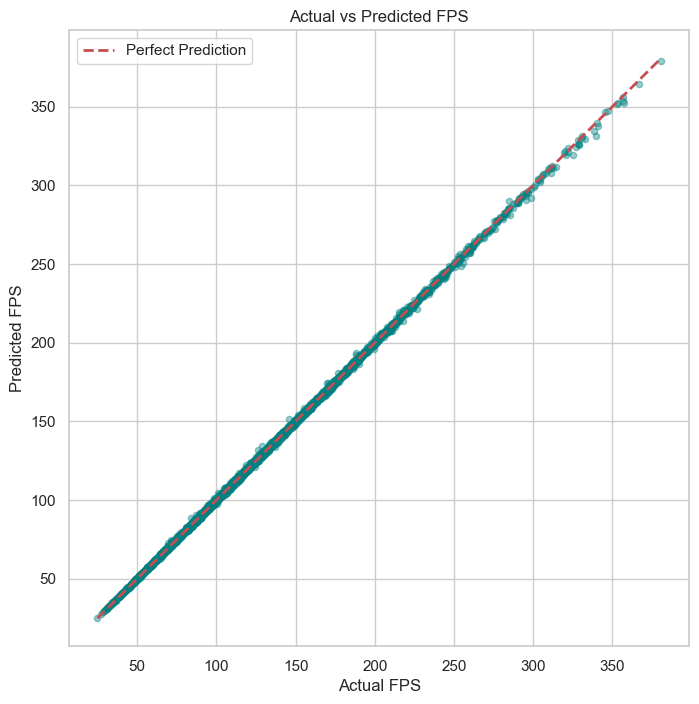

Generating Residuals Distribution Plot...


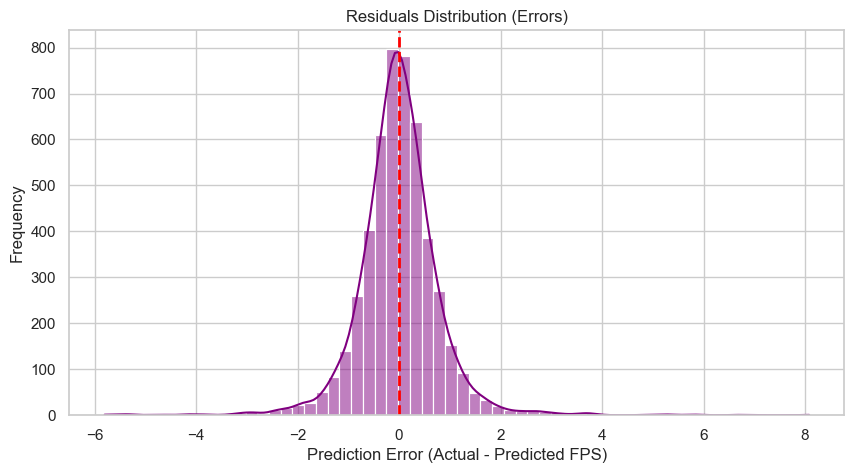

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


sns.set_theme(style="whitegrid")

# ==========================================
# 1. Model Comparison Plots
# ==========================================
print("Generating Model Comparison Plots...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison - R2 Score (Higher is Better)')
axes[0].set_xlim(0, 1)

sns.barplot(x='RMSE', y='Model', data=results_df, ax=axes[1], palette='flare')
axes[1].set_title('Model Comparison - RMSE (Lower is Better)')

plt.tight_layout()
plt.show()

# ==========================================
# 2. Learning Curve for the Best Model (XGBoost)
# ==========================================
print("Generating Learning Curve for the Best Model...")

train_sizes, train_scores, test_scores = learning_curve(
    best_model_pipeline, X_train, y_train, 
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = -train_scores.mean(axis=1)
test_scores_mean = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Error (RMSE)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Error (RMSE)")
plt.title("Learning Curve (XGBoost)")
plt.xlabel("Number of Training Examples")
plt.ylabel("RMSE (Lower is Better)")
plt.legend(loc="best")
plt.show()

# ==========================================
# 3. Actual vs Predicted Scatter Plot
# ==========================================
print("Generating Actual vs Predicted Plot...")
plt.figure(figsize=(8, 8))
plt.scatter(y_test, final_predictions, alpha=0.4, color='teal', s=20)

# رسم خط التطابق المثالي (Perfect Prediction Line)
min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs Predicted FPS')
plt.xlabel('Actual FPS')
plt.ylabel('Predicted FPS')
plt.legend()
plt.show()

# ==========================================
# 4. Residuals Distribution (Error Distribution)
# ==========================================
print("Generating Residuals Distribution Plot...")
residuals = y_test - final_predictions

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=60)
plt.axvline(x=0, color='red', linestyle='--', lw=2) 

plt.title('Residuals Distribution (Errors)')
plt.xlabel('Prediction Error (Actual - Predicted FPS)')
plt.ylabel('Frequency')
plt.show()

In [26]:
import joblib


model_filename = 'fps_pipeline.pkl'
joblib.dump(best_model_pipeline, model_filename)

print(f" {model_filename}")

 fps_pipeline.pkl
